# **UTS Eksplorasi dan Visualisasi Data**

Nama = Mareko Famaogombowo Nazara <br>
NIM = 20254920001<br>
Mata Kuliah = Ekplorasi dan Visualisasi Data

## **SOAL 1**
a. Jelaskan secara rinci apa yang dimaksud dengan Eksplorasi Data Analysis (EDA)!<br>
b. Mengapa penting untuk melakukan EDA sebelum melakukan analisis yang lebih lanjut?<br>
c. Pada California Housing Dataset variabel mana yang kemungkinan bisa dilakukan analisis distribusi
data, analisis korelasi, dan analisis regresi?<br>
d. Jelaskan kenapa variabel Lattitude dan Longitude tidak dimasukkan pada analisis distribusi data, analisis
korelasi, dan analisis regresi!

## Jawaban:

**a. Apa itu Exploratory Data Analysis (EDA)?** <br>
EDA adalah proses memahami, meringkas, dan memvisualisasikan karakteristik utama dataset sebelum melakukan pemodelan formal. Diperkenalkan John W. Tukey (1977), EDA mencakup:
- **Pemeriksaan struktur data** — jumlah baris/kolom, tipe data, preview awal
- **Deteksi missing values** — identifikasi data kosong dan strategi penanganannya
- **Deteksi outlier** — nilai ekstrem via boxplot, z-score, atau IQR
- **Analisis distribusi** — histogram, density plot untuk memahami sebaran tiap variabel
- **Analisis korelasi** — heatmap korelasi antar variabel
- **Visualisasi data** — scatter plot, bar chart, pairplot untuk mengungkap pola tersembunyi

**b. Mengapa EDA Penting Sebelum Analisis Lanjutan?** <br>
EDA bersifat krusial karena mencegah prinsip "Garbage In, Garbage Out":

- **Mencegah bias model** — data kotor menghasilkan output tidak valid meski model canggih
- **Mendeteksi asumsi yang dilanggar** — regresi linear butuh distribusi relatif normal; jika data sangat skewed, model akan bias
- **Memandu feature engineering** — menentukan variabel mana yang perlu transformasi (log, scaling) atau dihilangkan
- **Efisiensi komputasi** — membuang fitur tidak relevan sebelum pelatihan model
- **Komunikasi awal** — hasil EDA menjadi laporan awal kepada stakeholder sebelum masuk ke modeling

| Jenis Analisis | Variabel yang Direkomendasikan | Keterangan |
|---|---|---|
| **Distribusi Data** | Semua 9 variabel (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`, `MedHouseVal`) | Semua variabel bertipe numerik sehingga dapat dianalisis distribusinya |
| **Korelasi** | Semua 9 variabel | Prioritaskan pasangan `MedInc ↔ MedHouseVal` (korelasi terkuat) dan waspadai `AveRooms ↔ AveBedrms` (multikolinearitas tinggi) |
| **Regresi** | **Y:** `MedHouseVal` — **X:** `MedInc`, `HouseAge`, `AveRooms`, `Latitude`, `Longitude` | Hindari memasukkan `AveBedrms` bersama `AveRooms`; `Population` dan `AveOccup` perlu penanganan outlier terlebih dahulu |

**d. Mengapa Latitude & Longitude Dikecualikan?** <br>
Ada 4 alasan utama (detail tersedia di tab "Latitude & Longitude" pada dashboard):
1. Multikolinearitas Ekstrem (r = −0.925) — California membentang diagonal NW ke SE, membuat Lat & Long berkorelasi hampir sempurna. Memasukkan keduanya sekaligus merusak estimasi koefisien regresi secara fundamental.
2. Distribusi Uniform — Tidak Bermakna Statistik — Nilainya hanya mencerminkan batas geografis California (bukan fenomena sosial-ekonomi), sehingga histogram-nya datar dan tidak informatif untuk analisis distribusi.
3. Hubungan Non-Linear dengan Harga — Pengaruh lokasi terhadap harga bersifat spatial non-linear (pantai vs pedalaman, kota vs desa). Regresi linear tidak bisa menangkap pola ini dari koordinat mentah — diperlukan metode khusus seperti Geographically Weighted Regression (GWR).
4. Tidak Bermakna Secara Kausal — Bukan koordinat yang menyebabkan harga tinggi, melainkan fasilitas, aksesibilitas, dan karakteristik wilayah. Koordinat mentah adalah proxy tanpa interpretasi yang jelas.

## **SOAL 2:**
Lakukan  visualisasi  data  numerik  dari  dataset  California  Housing.  Gunakan  histogram  untuk  menampilkan distribusi dari variabel-variabel numerik, dan jelaskan apa yang bisa diambil dari visualisasi tersebut.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [3]:
data = pd.read_excel(r"C:\Users\Mareko\OneDrive\Documents\Python Statistika\DataSets\california_housing.xlsx")
print(data.head(101))

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0    8.3252        41  6.984127   1.023810         322  2.555556     37.88   
1    8.3014        21  6.238137   0.971880        2401  2.109842     37.86   
2    7.2574        52  8.288136   1.073446         496  2.802260     37.85   
3    5.6431        52  5.817352   1.073059         558  2.547945     37.85   
4    3.8462        52  6.281853   1.081081         565  2.181467     37.85   
..      ...       ...       ...        ...         ...       ...       ...   
96   2.8345        31  3.894915   1.127966        2048  1.735593     37.82   
97   2.0062        29  3.681319   1.175824         202  2.219780     37.81   
98   1.2185        22  2.945600   1.016000        2024  1.619200     37.82   
99   2.6104        37  3.707143   1.107143        1838  1.875510     37.82   
100  2.4912        29  3.724800   1.131200        2304  1.843200     37.81   

     Longitude  MedHouseVal  
0      -122.23        4.526  
1  

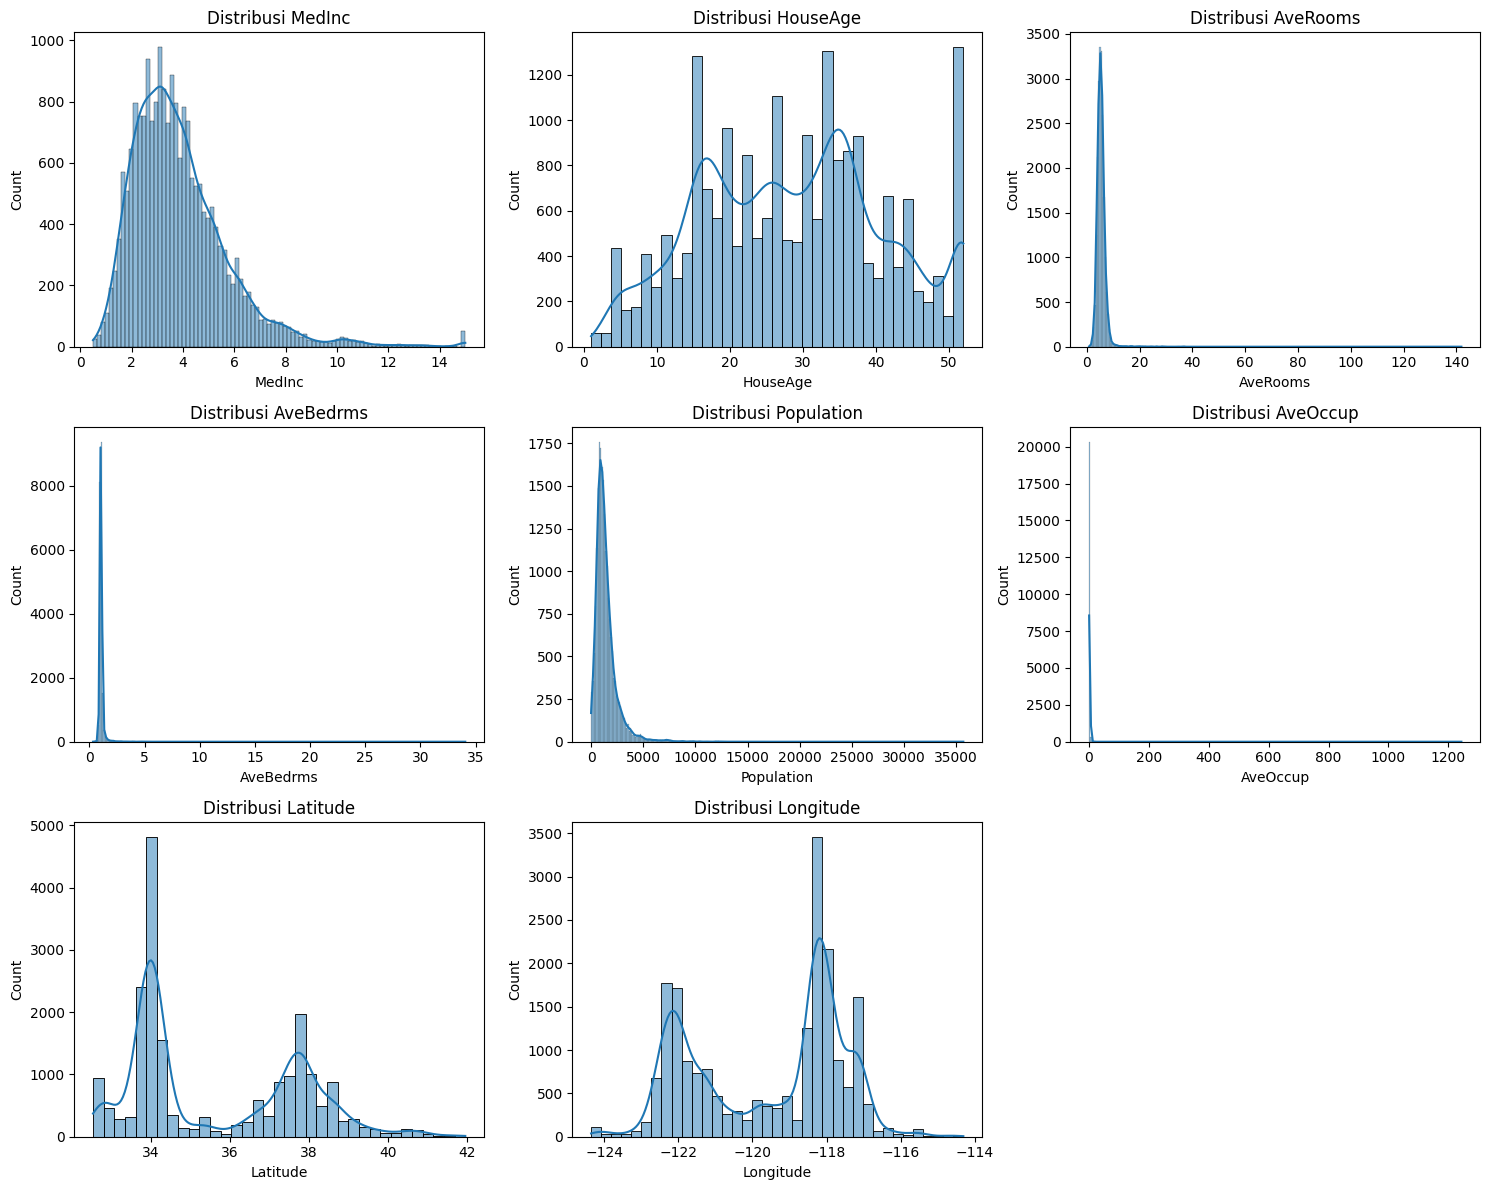

In [4]:
kolom = data.columns[:-1]
n = len(kolom)

# Hitung jumlah baris dan kolom grid secara otomatis
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(kolom):
    sns.histplot(data[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribusi {col}')

# Sembunyikan subplot kosong (jika jumlah kolom tidak habis dibagi ncols)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## **SOAL 3:** 
Tampilkan korelasi antar variabel numerik dalam dataset California Housing. Identifikasi variabel mana yang 
memiliki korelasi tertinggi dan terendah, dan jelaskan interpretasinya.

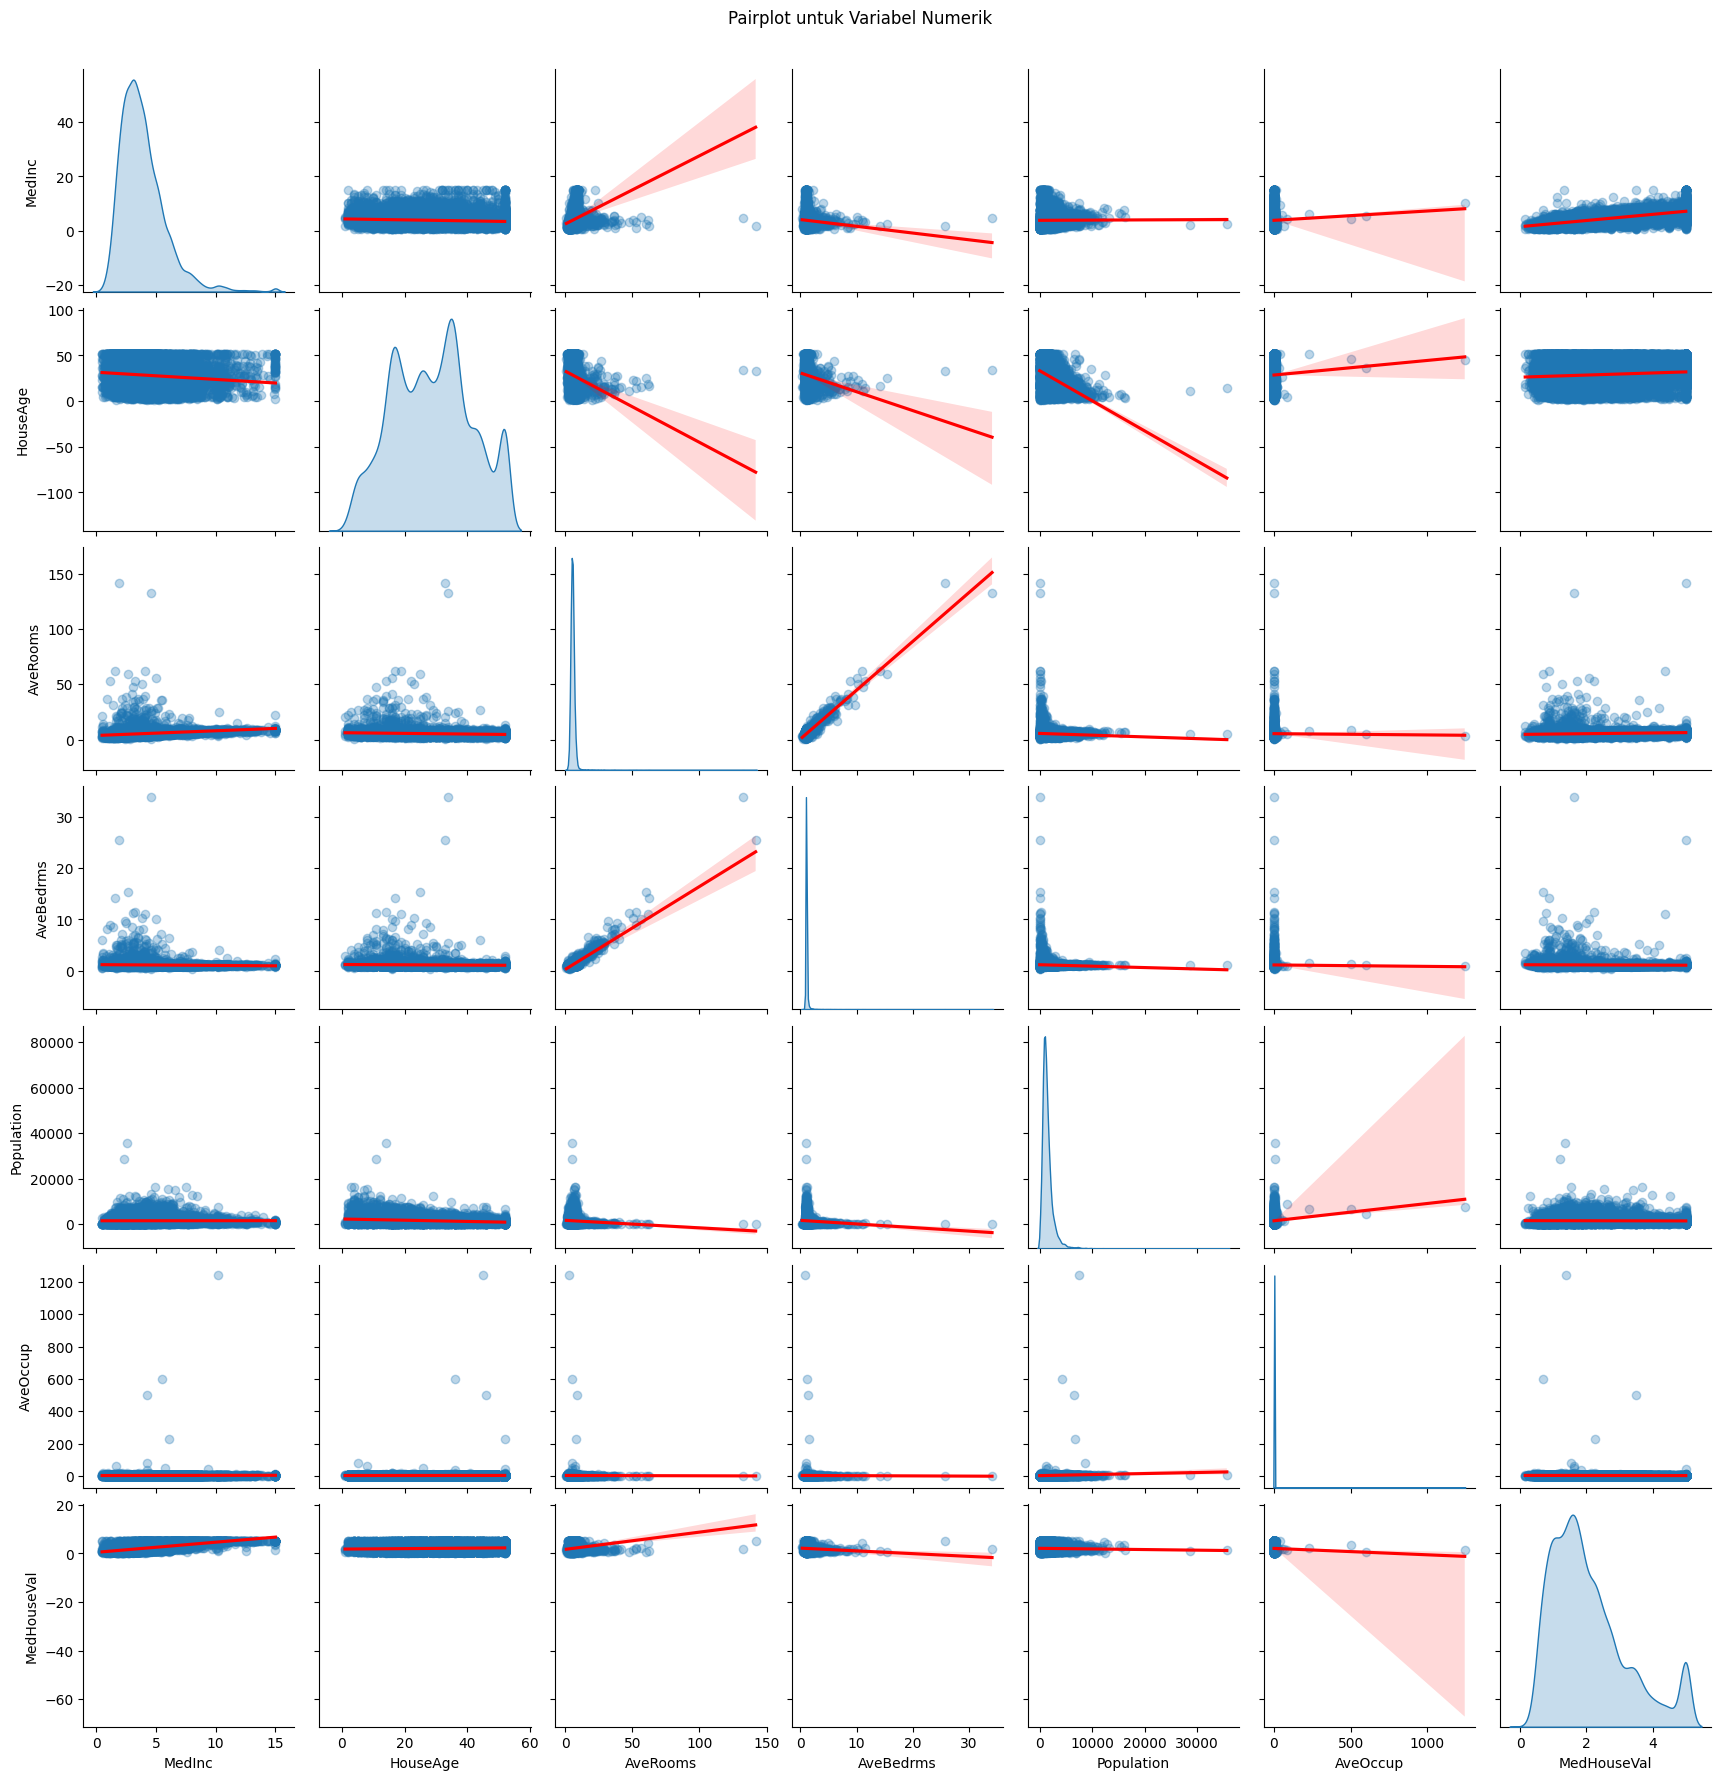

In [14]:
# Pilih kolom relevan (tanpa Latitude & Longitude)
kolom_relevan = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'MedHouseVal'
]

# Simpan hasil pairplot ke variabel 'g'
g = sns.pairplot(
    data[kolom_relevan],
    diag_kind='kde',        # diagonal: kurva distribusi
    kind='reg',       # off-diagonal: scatter plot
    plot_kws={
        'scatter_kws' :{'alpha': 0.3},
        'line_kws': {'color': 'red'}
    }# titik semi-transparan agar tidak penuh
)

# Judul dipasang lewat g.fig, bukan plt
g.fig.suptitle("Pairplot untuk Variabel Numerik", y=1.02)
plt.show()

## **SOAL 4:** 
Lakukan  Analisis  Regresi  Berganda  dan  gunakan  variabel  MedInc  sebagai  variabel  dependen.  Berikan 
penjelasan mengenai nilai R-squared dan variabel mana yang paling berpengaruh terhadap variabel dependen.

Mean Squared Error: 0.64
Root Mean Squared Error: 0.80
R-squared: 0.51


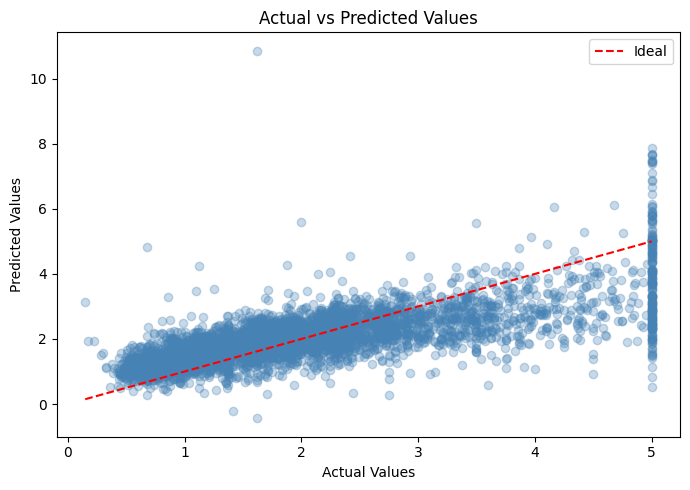

In [20]:
X = data[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']]
Y = data['MedHouseVal']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

koef = pd.DataFrame(
    {
        'Feature': X.columns,
        'Coefficient': model.coef_
    }
)

plt.figure(figsize=(7, 5))
plt.scatter(Y_test, Y_pred, alpha=0.3, color='steelblue')
plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    color='red',
    linewidth=1.5,
    label='Ideal',
    linestyle='--'
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

## **SOAL 5:** 
1. Jelaskan, apakah Anda dapat mengaplikasikan konsep Analisis Time Series pada data California 
Housing? 
2. Jelaskan konsep-konsep penting tren, musiman, dan noise dalam analisis time series!